# Get started with Earth Engine for Python

This quickstart will give you an interactive introduction to visualizing and
analyzing geospatial data with the Earth Engine Python interface.

## Before you begin

[Register or create](https://code.earthengine.google.com/register) a Google Cloud Project; you'll be prompted to complete the following steps. If you already have a project registered for Earth Engine access, skip to the next section.

  * Select noncommercial.
  * Project type: 
  * Create a new Google Cloud project or select an existing project.
  * Confirm your project information.  




## Notebook setup

**1.** Import the Earth Engine and geemap libraries.

In [1]:
import ee
import geemap.core as geemap

**2.** Authenticate and initialize the Earth Engine service. Follow the
resulting prompts to complete authentication. Be sure to replace PROJECT_ID
with the name of the project you set up for this quickstart.

In [2]:
ee.Authenticate()
ee.Initialize(project='riftwaters')


3. Select a region of interest and time range

In [5]:
##Lake baringo

ROI = ee.Geometry.Polygon(
            [
                [35.98391292157122, 0.4153611370519164],
                [36.16518733563372, 0.4153611370519164],
                [36.16518733563372, 0.7446867187538047],
                [35.98391292157122, 0.7446867187538047],
            ]
        )

roi = ee.Geometry.Polygon(
            [
                [36.021644575238554, 0.15353594768753728],
                [36.18025968754324, 0.15353594768753728],
                [36.18025968754324, 0.36364721537653627],
                [36.021644575238554, 0.36364721537653627],
                [36.021644575238554, 0.15353594768753728],
            ])

start_date = '2021-12-01'   ## ensure dates are in the format 'YYYY-MM-DD'
end_date = '2021-12-31'

In [ ]:
#image = ee.FeatureCollection()


4. Downloading Images from various catalogs

In [ ]:
##Downloading sentinel-1 image collection
S1_image = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterDate(start_date, end_date)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    .select("HV")
)


count = S1_image.size().getInfo()
print(f"  Found {count} images")


# Apply preprocessing
def preprocess_sar(image):
    # Apply thermal noise removal, radiometric calibration, and terrain correction
    image = image.select("HV")
    image = image.focal_median(radius=10, units="meters")
    return image.clip(roi)

processed = S1_image.map(preprocess_sar)

# Create median composite
composite = processed.median()

# Get list of images

        
m = geemap.Map()
m.set_center(36., 0.6, 12)
m.add_layer(composite, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
m

In [ ]:



def mask_edge(image):
  edge = image.lt(-30.0)
  masked_image = image.mask().And(edge.Not())
  return image.updateMask(masked_image).clip(roi)


img_vv = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(ROI)
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .select('VV')
    .map(mask_edge)
)

desc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).median()
asc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')).median()




m = geemap.Map()
m.set_center(36., 0.6, 12)
#m.add_layer(asc, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
m.add_layer(desc, {'min': -25, 'max': 5}, 'Multi-T Mean DESC', True)
m

In [ ]:
# Load Sentinel-2 image collection
def mask_s2_clouds(image):
    qa = image.select("QA60")
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask)

s2_image = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(ROI)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", 20))
)
count = s2_image.size().getInfo()
print(f"Found {count} Sentinel-2 images")




s2_image = s2_image.map(mask_s2_clouds)
s2_image = s2_image.median().clip(roi)


visualization = {
    "min": 0.0,
    "max": 1000,
    "bands": ["B4", "B3", "B2"],
}

m = geemap.Map()
m.set_center(36., 0.6, 10)
m.add_layer(s2_image, visualization, "RGB")
m

Saving an Image

In [ ]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("/home/desy/rift-waters/dataset/bogoria/processed/sar_water_mask/bogoria_20211231.tif") as src:
    image = src.read(1)
    
    print(image.shape)
    print(image.min(), image.max())
    plt.imshow(image, cmap='grey')
    plt.colorbar()
    plt.show()

In [ ]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("/home/desy/rift-waters/dataset/bogoria/raw/dem/bogoria_20211231_dem_wbm.tif") as src:
    image = src.read(2)
    
    print(image.shape)
    print(image.min(), image.max())
    plt.imshow(image, cmap='BuGn')
    plt.colorbar()
    plt.show()

In [ ]:
n = "2021-12-31"
print(int(n.replace("-", "")))

In [ ]:


# Define the local file path and the destination asset ID
local_tiff = '/home/desy/rift-waters/dataset/bogoria/processed/sar_water_mask/bogoria_20211231.tif'
asset_id = 'dataset/bogoria/processed/sar_water_mask/bogoria_20211231'

# Upload the local TIFF to GEE Assets
geemap.ee_upload_image(local_tiff, asset_id)

# Load the uploaded image as an ee.Image object
ee_image = ee.Image(asset_id)   

## Add raster data to a map

**1.** Load climate data for a given period and display its metadata.

**2.** Instantiate a map object and add the temperature band as a layer with
specific visualization properties. Display the map.

## Add vector data to a map

**1.** Create a vector data object with points for three cities.

**2.** Add the city locations to the map and redisplay it.

## Extract and chart data

**1.** Import the Altair charting library.

**2.** Extract the climate data for the three cities as a pandas DataFrame.

**3.** Plot the temperature for the cities as a bar chart.

## What's next

  * Learn about analyzing data with Earth Engine's [objects and methods](https://developers.google.com/earth-engine/guides/objects_methods_overview).
  * Learn about Earth Engine's [processing environments](https://developers.google.com/earth-engine/guides/processing_environments).
  * Learn about Earth Engine's [machine learning capabilities](https://developers.google.com/earth-engine/guides/machine-learning).
  * Learn how to [export your computation results to BigQuery](https://developers.google.com/earth-engine/guides/exporting_to_bigquery).


    # ===== LAKE DIRECT COLUMNS (KEEP ALL) =====
        'lake_bottom_temperature',
        'lake_mix_layer_depth', 
        'lake_mix_layer_temperature',
        'lake_total_layer_temperature',
        'lake_bottom_temperature_min', 'lake_bottom_temperature_max',
        'lake_mix_layer_depth_min', 'lake_mix_layer_depth_max',
        'lake_mix_layer_temperature_min', 'lake_mix_layer_temperature_max',
        'lake_total_layer_temperature_min', 'lake_total_layer_temperature_max',
        
        # ===== WATER INPUT (PRECIPITATION & RUNOFF) =====
        'total_precipitation_sum',
        'total_precipitation_min', 'total_precipitation_max',
        'runoff_sum',
        'runoff_min', 'runoff_max',
        'surface_runoff_sum',
        'surface_runoff_min', 'surface_runoff_max',
        'sub_surface_runoff_sum',
        'sub_surface_runoff_min', 'sub_surface_runoff_max',
        
        # ===== WATER LOSS (EVAPORATION) =====
        'total_evaporation_sum',
        'total_evaporation_min', 'total_evaporation_max',
        'evaporation_from_open_water_surfaces_excluding_oceans_sum',
        'evaporation_from_open_water_surfaces_excluding_oceans_min',
        'evaporation_from_open_water_surfaces_excluding_oceans_max',
        'evaporation_from_bare_soil_sum',
        
        # ===== THERMAL/ENERGY (CRITICAL FOR EQUATORIAL LAKES) =====
        'skin_temperature',
        'skin_temperature_min', 'skin_temperature_max',
        'temperature_2m',
        'temperature_2m_min', 'temperature_2m_max',
        'dewpoint_temperature_2m',
        'surface_net_solar_radiation_sum',
        'surface_net_thermal_radiation_sum',
        'surface_sensible_heat_flux_sum',
        'surface_latent_heat_flux_sum',
        'surface_solar_radiation_downwards_sum',
        'surface_thermal_radiation_downwards_sum',
        
        # ===== ATMOSPHERIC =====
        'surface_pressure',
        'surface_pressure_min', 'surface_pressure_max',
        'u_component_of_wind_10m',
        'v_component_of_wind_10m',
        
        # ===== SOIL MOISTURE (GROUNDWATER CONTRIBUTION) =====
        'volumetric_soil_water_layer_1',
        'volumetric_soil_water_layer_2',
        'volumetric_soil_water_layer_3',
        'volumetric_soil_water_layer_4',
        
        # ===== IDENTIFICATION =====

In [ ]:
soil_water= ['volumetric_soil_water_layer_1',
        'volumetric_soil_water_layer_2',
        'volumetric_soil_water_layer_3',
        'volumetric_soil_water_layer_4']



In [37]:
# climate ee.Image("MERIT/Hydro/v1_0_1")
import pandas as pd

era5 = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .select("temperature_2m")
    .filterBounds(ROI)
    .filterDate(start_date, end_date)
    .mosaic()
    .reduce(ee.Reducer.mean())
)


visualization = {
    "bands": ["temperature_2m"],
    "min": 250,
    "max": 320,
    "palette": [
        "000080",
        "0000d9",
        "4000ff",
        "8000ff",
        "0080ff",
        "00ffff",
        "00ff80",
        "80ff00",
        "daff00",
        "ffff00",
        "fff500",
        "ffda00",
        "ffb000",
        "ffa400",
        "ff4f00",
        "ff2500",
        "ff0a00",
        "ff00ff",
    ],
}


# Extract to DataFrame


m = geemap.Map()
m.set_center(36.0, 0.6, 10)
# m.add_layer(era5, visualization, "Air temperature [K] at 2m height", True, 0.8)

In [54]:
data = era5.getRegion(ROI, scale=1000).getInfo()
df = pd.DataFrame(data[1:], columns=data[0])
# df.to_csv("era5_MONTHLY.csv")

In [55]:
df

,id,longitude,latitude,time,total_precipitation_sum
0,20260101,35.991002,0.417717,1767225600000,4.914969e-04
1,20260102,35.991002,0.417717,1767312000000,8.523464e-07
2,20260103,35.991002,0.417717,1767398400000,3.010714e-06
3,20260104,35.991002,0.417717,1767484800000,2.220273e-06
4,20260105,35.991002,0.417717,1767571200000,0.000000e+00
...,...,...,...,...,...
133935,20260626,36.161682,0.741110,1782432000000,1.523495e-04
133936,20260627,36.161682,0.741110,1782518400000,4.649162e-06
133937,20260628,36.161682,0.741110,1782604800000,4.086256e-04
133938,20260629,36.161682,0.741110,1782691200000,9.880967e-05


In [49]:
# mean = image.reduceRegion(
#         reducer=ee.Reducer.mean(),
#         geometry=ROI,
#         scale=9000,
#         bestEffort=True
#     )
#from matplotlib import scale
import geemap

# geemap.ee_export_image(
#                     era5,
#                     filename="2mtemp.tif",
#                     region=ROI,
#                 )

data = era5.aggregate_array('total_precipitation_sum').getInfo()
print(data)
df = pd.DataFrame(data)
#df.to_csv("era5_MONTHLY.csv")
df.head(12)

[]


""


In [57]:
import pandas as pd

# Load the collection
era5 = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
        .select('total_precipitation_sum',  ).filterBounds(ROI)
        .filterDate(start_date, end_date))

# Define your polygon


# Define the function to add mean precipitation as a property
def add_mean_precip(image):
    mean = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=ROI,
        scale=9000,
        bestEffort=True
    )
    return image.set('mean_precip', mean.get('total_precipitation_sum'))

# Apply the function to the collection
daily_averages = era5.map(add_mean_precip)
print(daily_averages.getInfo())
daily_averages_list = daily_averages.aggregate_array('mean_precip').getInfo()
daily_averages_df = pd.DataFrame(daily_averages_list, columns=['mean_precipitation'])
#daily_averages_df.to_csv("era5_daily_precipitation.csv")
daily_averages_df

{'type': 'ImageCollection', 'bands': [], 'version': 1784272611851082, 'id': 'ECMWF/ERA5_LAND/DAILY_AGGR', 'features': [{'type': 'Image', 'bands': [{'id': 'total_precipitation_sum', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'dimensions': [3601, 1801], 'crs': 'EPSG:4326', 'crs_transform': [0.1, 0, -180.05, 0, -0.1, 90.05]}], 'version': 1784272611851082, 'id': 'ECMWF/ERA5_LAND/DAILY_AGGR/20211201', 'properties': {'mean_precip': 9.042483405713848e-07, 'system:time_start': 1638316800000, 'month': 12, 'year': 2021, 'system:footprint': {'type': 'LinearRing', 'coordinates': [[-180, -90], [180, -90], [180, 90], [-180, 90], [-180, -90]]}, 'system:time_end': 1638403200000, 'system:asset_size': 940030671, 'day': 1, 'system:index': '20211201'}}, {'type': 'Image', 'bands': [{'id': 'total_precipitation_sum', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'dimensions': [3601, 1801], 'crs': 'EPSG:4326', 'crs_transform': [0.1, 0, -180.05, 0, -0.1, 90.05]}], 'version': 178427

,mean_precipitation
0,9.042483e-07
1,3.689471e-03
2,5.833246e-03
3,2.575779e-04
4,2.384960e-04
5,8.865001e-05
6,2.660626e-05
7,1.968708e-04
8,7.381462e-05
9,8.523463e-07


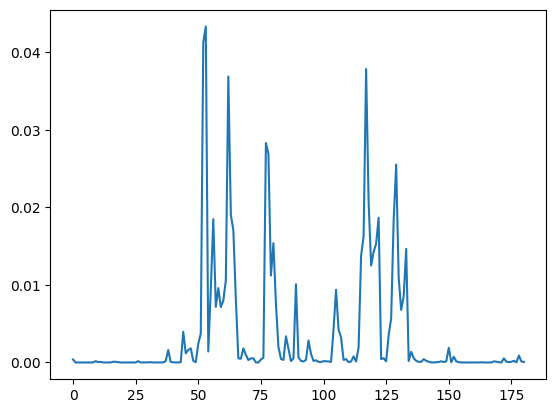

In [53]:
import matplotlib.pyplot as plt

plt.plot(daily_averages_df['mean_precipitation'])
plt.show()

In [50]:
era5 = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
        .select('total_precipitation_sum')
        .filterDate('2026-01-01', '2026-07-01'))

# Define your polygon (replace with your actual coordinates)
polygon = ee.Geometry.Polygon([
    [[-100.0, 40.0], [-99.0, 40.0], [-99.0, 41.0], [-100.0, 41.0]]
])

# Map over the collection to calculate daily averages
def calculate_mean(image):
    mean = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=polygon,
        scale=9000,  # ERA5-Land native resolution in meters
        bestEffort=True
    )
    return image.set('mean_precip', mean.get('total_precipitation_sum'))

daily_averages = era5.map(calculate_mean)

# Extract the results as a list of features
# Get dates and mean precipitation values
def extract_data(image):
    date = image.date().format('YYYY-MM-dd')
    mean_precip = image.get('mean_precip')
    return ee.Feature(None, {'date': date, 'mean_precip': mean_precip})

features = daily_averages.map(extract_data)

# Convert to a pandas DataFrame for analysis
df = geemap.ee_to_pandas(features)
print(df.head())

AttributeError: module 'geemap' has no attribute 'ee_to_pandas'

In [ ]:

df = pd.DataFrame(era5[1:], columns=era5[0])
df.to_csv("era5_MONTHLY2.csv")
df.head(12)

In [8]:
daily_averages_list = daily_averages.aggregate_array('mean_precip').getInfo()
print(daily_averages_list)
df = pd.DataFrame(daily_averages)
#df.to_csv("era5_MONTHLY.csv", index=False)
df.head()

[0.00038801948280933887, 8.523463748133508e-07, 3.060961807703305e-06, 6.303778873212917e-06, 0, 1.7163932852781727e-06, 0, 2.5654608180047944e-06, 1.7225742112714215e-06, 0.00016920962660695046, 5.221765455299798e-05, 7.456767508165406e-05, 3.856548536507392e-06, 2.8491149071898272e-09, 1.2963688504896709e-06, 1.7205434232892003e-06, 9.574197560616404e-05, 8.568651608700513e-05, 3.833565975259418e-05, 1.3385891109350882e-06, 0, 9.06455436313506e-07, 8.523463748133508e-07, 8.553265615773853e-07, 8.67841549734294e-07, 1.2785692524631824e-06, 0.00016601308720895142, 3.609254525274065e-06, 6.762893966788478e-06, 1.2993812106287805e-06, 1.3067767653365522e-05, 4.067604574843138e-05, 0, 2.1516434571822174e-06, 3.00916417472763e-06, 4.827265772079165e-06, 5.733365687403843e-06, 0.00018176843888084688, 0.0016077860588866904, 6.527098564411775e-05, 2.978883167821833e-05, 4.351138045421976e-07, 3.004073732881807e-06, 4.341298031267543e-05, 0.003954881319868123, 0.0011765944145985879, 0.00161257

ValueError: DataFrame constructor not properly called!

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# daily = pd.read_csv("era5.csv")

monthly = pd.read_csv("/home/desy/rift-waters/dataset/bogoria/metadata/bogoria_sar.csv")

monthly.head()
#print(monthly[])

,image_id,total_pixels,water_pixels,water_area_m2,boundary_area_m2,boundary_perimeter_m,boundary_compactness,method,processed_at
0,20160131.0,460790,46404,4640400,4.155767e+07,83680.099197,0.302714,NaN,NaN
1,20160229.0,460790,43816,4381600,3.923989e+07,63930.505751,0.120648,NaN,NaN
2,20160331.0,460790,47208,4720800,4.227758e+07,97494.926764,0.316186,NaN,NaN
3,20160430.0,460790,43082,4308200,3.858252e+07,63091.761022,0.121802,NaN,NaN
4,20160531.0,460790,43859,4385900,3.927840e+07,63149.404072,0.123773,NaN,NaN


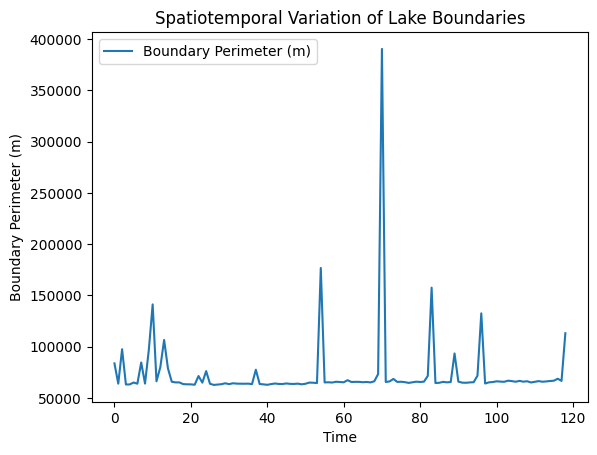

In [15]:
plt.plot(monthly["boundary_perimeter_m"], label="Boundary Perimeter (m)")
plt.xlabel("Time")
plt.ylabel("Boundary Perimeter (m)")
plt.title("Spatiotemporal Variation of Lake Boundaries")
plt.legend()
plt.show()

In [ ]:
# Get all column names
# df.columns.tolist()

# # Get column names as a list
# list(df.columns)

# Get column names as an Index object

print(df.columns)